In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.models.lgbm_train import train_lightgbm
from src.models.catboost_train import train_catboost
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly to avoid custom wrapper issues
import sklearn.metrics as skm
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")


In [2]:
features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")
split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()
vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()
iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

logger.info("Rebalancing VNAT splits for robust evaluation...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx]
vnat_temp = vnat_df.iloc[temp_idx]
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx]
vnat_test = vnat_temp.iloc[test_idx]
vnat_train["split"], vnat_val["split"], vnat_test["split"] = "train", "val", "test"
vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test])
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
logger.info(f"Enforcing Voipbuster splits: {vb_train_cap} -> TRAIN, {vb_test_cap} -> TEST")
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Final splits after rebalancing:\n", df_all["split"].value_counts())

# --- PRE-FLIGHT CHECKS (Added by Expert Assistant) ---
logger.info("Running Pre-flight Diagnostics...")

# 1. Check for Leakage Columns
temp_pipe = FeaturePipeline()
temp_pipe.fit(df_all[df_all["split"] == "train"])
feat_cols = temp_pipe.model_feature_names()
print(f"Detected {len(feat_cols)} features.")
print("First 30 features:", feat_cols[:30])
suspicious = [c for c in feat_cols if any(x in c.lower() for x in ['id', 'label', 'split', 'pcap', 'capture', 'time', 'date'])]
if suspicious:
    print(f"WARNING: Suspicious feature names found: {suspicious}")

# 2. Zero Variance Check
X_train_check = temp_pipe.transform(df_all[df_all["split"] == "train"])
X_train_vals = X_train_check[feat_cols]
variances = X_train_vals.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"WARNING: Found {len(zero_var_cols)} zero-variance features: {zero_var_cols}")

# 3. Random Label Test (Improved: 20 seeds, 200 trees, Test set, Explicit sklearn)
logger.info("Running Random Label Smoke Test (20 seeds, 200 trees, Test set)...")
print("skm.roc_auc_score module:", skm.roc_auc_score.__module__)

# Debug: Print label counts
df_train_check = df_all[df_all["split"] == "train"]
df_test_check = df_all[df_all["split"] == "test"]
print("TRAIN label counts:", np.bincount(df_train_check["label"].astype(int)))
print("TEST label counts:", np.bincount(df_test_check["label"].astype(int)))

aucs = []
for seed in range(20):
    df_noise = df_train_check.copy()
    # Permute labels to preserve class balance
    df_noise["label"] = np.random.default_rng(seed).permutation(df_noise["label"].values)

    # Use temp_pipe features
    X_noise = temp_pipe.transform(df_noise)
    y_noise = df_noise["label"]

    # Use more robust model settings
    model_noise = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="logloss", random_state=seed, n_jobs=1)
    model_noise.fit(X_noise[feat_cols], y_noise)

    # Eval on real TEST set (more stable than Val)
    X_test_check = temp_pipe.transform(df_test_check)
    y_test_real = df_test_check["label"]

    preds = model_noise.predict_proba(X_test_check[feat_cols])[:, 1]
    score = skm.roc_auc_score(y_test_real, preds)
    aucs.append(score)

    # Debug check for first run
    if seed == 0:
        auc_inv = skm.roc_auc_score(y_test_real, 1 - preds)
        print(f"DEBUG (seed 0): AUC(p)={score:.4f}, AUC(1-p)={auc_inv:.4f}")

print(f"Random Label AUCs (Test): {aucs}")
print(f"Mean Random Label AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

# 4. Correct Capture Holdout Test (Robust: Stratified Sampling)
logger.info("Running Robust Capture Holdout Test (Stratified Sampling)...")

# Get capture-level labels
vnat_train_df = df_all[(df_all["dataset"]=="vnat") & (df_all["split"]=="train")]
cap_labels = vnat_train_df.groupby("capture_id")["label"].max()

pos_caps = cap_labels[cap_labels==1].index.to_numpy()
neg_caps = cap_labels[cap_labels==0].index.to_numpy()

K_POS, K_NEG = 2, 3
N_RUNS = 20
holdout_aucs = []

for i in range(N_RUNS):
    rng = np.random.default_rng(100 + i)
    # Ensure we have enough captures to sample from
    if len(pos_caps) < K_POS or len(neg_caps) < K_NEG:
        print("WARNING: Not enough captures for stratified holdout.")
        break

    holdout_caps = np.concatenate([
        rng.choice(pos_caps, K_POS, replace=False),
        rng.choice(neg_caps, K_NEG, replace=False),
    ])

    mask_holdout = df_all["capture_id"].isin(holdout_caps)
    df_ho_test = df_all[mask_holdout]
    df_ho_train = df_all[(~mask_holdout) & (df_all["split"]=="train")]

    # CRITICAL: Fit NEW pipeline
    pipe_ho = FeaturePipeline().fit(df_ho_train)
    ho_feats = pipe_ho.model_feature_names()

    X_tr = pipe_ho.transform(df_ho_train)[ho_feats]
    X_te = pipe_ho.transform(df_ho_test)[ho_feats]

    model_ho = xgb.XGBClassifier(n_estimators=50, max_depth=3, eval_metric="logloss", random_state=100+i, n_jobs=1)
    model_ho.fit(X_tr, df_ho_train["label"])

    p = model_ho.predict_proba(X_te)[:,1]

    holdout_aucs.append(skm.roc_auc_score(df_ho_test["label"], p))

if holdout_aucs:
    print(f"Holdout AUC mean±std (over {len(holdout_aucs)} runs): {np.mean(holdout_aucs):.4f} +/- {np.std(holdout_aucs):.4f}")
else:
    print("WARNING: No valid holdout runs completed.")

# 5. Cross-Domain Smoke Test (VNAT Train -> ISCX Test Only)
logger.info("Running VNAT -> ISCX Smoke Test...")
vnat_train_only = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "train")]
iscx_test_only = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")]

if len(vnat_train_only) > 0 and len(iscx_test_only) > 0:
    pipe_cross = FeaturePipeline().fit(vnat_train_only)
    X_cross_train = pipe_cross.transform(vnat_train_only)
    X_cross_test = pipe_cross.transform(iscx_test_only)
    cross_feats = pipe_cross.model_feature_names()

    # DEBUG: Dump shapes and labels for comparison with notebook 16
    print("DEBUG Cross-Domain (NB10):")
    print("VNAT train shape:", X_cross_train[cross_feats].shape)
    print("ISCX test shape:", X_cross_test[cross_feats].shape)
    print("ISCX test label counts:", np.bincount(iscx_test_only["label"].astype(int)))

    model_cross = xgb.XGBClassifier(n_estimators=30, max_depth=3, eval_metric="logloss", random_state=42, n_jobs=1)
    model_cross.fit(X_cross_train[cross_feats], vnat_train_only["label"])

    preds_cross = model_cross.predict_proba(X_cross_test[cross_feats])[:, 1]

    # Save for comparison
    np.save(paths.artifacts_dir / "debug_y_iscx_nb10.npy", iscx_test_only["label"].astype(int).to_numpy())
    np.save(paths.artifacts_dir / "debug_p_iscx_nb10.npy", preds_cross)

    auc_cross = skm.roc_auc_score(iscx_test_only["label"], preds_cross)
    print(f"VNAT -> ISCX AUC: {auc_cross:.4f}")
    if auc_cross > 0.99:
        print("WARNING: Perfect AUC on Cross-Domain test suggests LEAKAGE.")

logger.info("Fitting and saving new FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

2026-02-28 14:57:09 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-02-28 14:57:46 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-02-28 14:58:09 | INFO | ai-vpn-firewall | Rebalancing VNAT splits for robust evaluation...
2026-02-28 14:58:09 | INFO | ai-vpn-firewall | Enforcing Voipbuster splits: vpn_vpn_voipbuster1a.pcap -> TRAIN, vpn_vpn_voipbuster1b.pcap -> TEST
Final splits after rebalancing:
 split
train    9428
val      2423
test     1138
Name: count, dtype: int64
2026-02-28 14:58:09 | INFO | ai-vpn-firewall | Running Pre-flight Diagnostics...
Detected 54 features.
First 30 features: ['f_up_pkt_ratio', 'f_up_byte_ratio', 'f_iat_burstiness', 'sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_up_mean', 'sz_up_std', 'sz_up_p25', 'sz_up_median', 'sz_up_p75', 'sz_down_mean', 'sz_down_std', 'sz_down_p25', 'sz_down_median', 'sz_down_p75', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_up_mean',

In [3]:
# 2. Train Individual Models
logger.info("\n" + "="*60 + "\nTraining XGBoost...")
xgb_res = train_xgboost(paths=paths, xgb_yaml=paths.configs_dir / "xgb.yaml", df=df_all)
print_metrics_summary(xgb_res.metrics)

logger.info("\n" + "="*60 + "\nTraining LightGBM...")
lgbm_res = train_lightgbm(paths=paths, lgbm_yaml=paths.configs_dir / "lgbm.yaml", df=df_all)
print_metrics_summary(lgbm_res.metrics)

logger.info("\n" + "="*60 + "\nTraining CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
print_metrics_summary(cat_res.metrics)


2026-02-28 14:58:21 | INFO | ai-vpn-firewall | 
Training XGBoost...
DEBUG mean/std (first 5):
[-0.  0. -0. -0. -0.]
[1. 1. 1. 1. 1.]
[0]	train-logloss:0.65483	train-auc:0.97748	train-aucpr:0.93184	val-logloss:0.67176	val-auc:0.86332	val-aucpr:0.75330
[100]	train-logloss:0.07407	train-auc:0.99868	train-aucpr:0.99664	val-logloss:0.26216	val-auc:0.98721	val-aucpr:0.97692
[200]	train-logloss:0.03763	train-auc:0.99969	train-aucpr:0.99912	val-logloss:0.19070	val-auc:0.99305	val-aucpr:0.98713
[300]	train-logloss:0.02305	train-auc:0.99991	train-aucpr:0.99973	val-logloss:0.15174	val-auc:0.99531	val-aucpr:0.99101
[400]	train-logloss:0.01610	train-auc:0.99997	train-aucpr:0.99991	val-logloss:0.13663	val-auc:0.99580	val-aucpr:0.99188
[500]	train-logloss:0.01204	train-auc:0.99999	train-aucpr:0.99997	val-logloss:0.12539	val-auc:0.99613	val-aucpr:0.99253
[600]	train-logloss:0.00964	train-auc:0.99999	train-aucpr:0.99998	val-logloss:0.11708	val-auc:0.99634	val-aucpr:0.99287
[700]	train-logloss:0.00800	t

In [4]:
logger.info("\n" + "="*60 + "\nCreating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
print_metrics_summary(ens_res.metrics)

# NOTE: Calibration is now handled INSIDE create_ensemble, so we don't need to do it again here.
# We just load the already-calibrated predictions for the final report.
df_ens_preds = pd.read_parquet(ens_res.preds_path)


2026-02-28 14:58:49 | INFO | ai-vpn-firewall | 
Creating and Evaluating Ensemble...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble...

EVALUATION SUMMARY
Global Threshold: 0.5

--- Raw Probabilities ---

Split: TRAIN
  N: 9428 (Pos: 2325, Neg: 7103)
  ROC AUC: 1.0
  PR AUC:  1.0
  At Threshold 0.5:
    Precision: 1.0
    Recall:    1.0
    F1 Score:  1.0
    Confusion Matrix: TN=7103, FP=0, FN=0, TP=2325

Split: TEST
  N: 1138 (Pos: 246, Neg: 892)
  ROC AUC: 0.9898191694921433
  PR AUC:  0.9772981351909172
  At Threshold 0.5:
    Precision: 0.9744680851063829
    Recall:    0.9308943089430894
    F1 Score:  0.9521829521829522
    Confusion Matrix: TN=886, FP=6, FN=17, TP=229

Split: VAL
  N: 2423 (Pos: 746, Neg: 1677)
  ROC AUC: 0.9974773029202857
  PR AUC:  0.9948047017313361
  At Threshold 0.5:
    Precision: 0.9466145833333334
    Recall:    0.9745308310991957
    F1 Score:  0.9603698811096433
    Confus

In [5]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import precision_recall_fscore_support

print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

df_preds = pd.read_parquet(ens_res.preds_path)
metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# Artifact Consistency Check
print("\n--- Artifact Consistency Check ---")
# Check if preds file has the same hash as current config
# (In a real production system, we'd store the hash in the parquet metadata or a sidecar file)
# Here we just check if the pipeline used matches the current one
current_hash = feature_config_hash_text(features_yaml)
print(f"Current Feature Config Hash: {current_hash}")
# We can't easily check the parquet file's provenance without extra metadata,
# but we can check if the feature columns match.
saved_pipe = FeaturePipeline.load(feature_art)
if saved_pipe.model_feature_names() != pipeline.model_feature_names():
    print("WARNING: Saved pipeline features do not match current pipeline features!")
else:
    print("CONFIRMED: Pipeline features match.")


T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]
y_hat_block = (p_calib >= T_BLOCK).astype(int)
prec_block, rec_block, _, _ = precision_recall_fscore_support(y_true, y_hat_block, average="binary", zero_division=0)
_, fp_b, _, _ = confusion_matrix(y_true, y_hat_block).ravel()
y_hat_monitor = (p_calib >= T_MONITOR).astype(int)
prec_monitor, rec_monitor, _, _ = precision_recall_fscore_support(y_true, y_hat_monitor, average="binary", zero_division=0)
_, fp_m, _, _ = confusion_matrix(y_true, y_hat_monitor).ravel()

print(f"\nBLOCK ZONE (p >= {T_BLOCK:.4f})")
print(f"  - Recall:    {rec_block:.4f}")
print(f"  - Precision: {prec_block:.4f}")
print(f"  - False Positives: {fp_b} flows")

print(f"\nMONITOR ZONE (p >= {T_MONITOR:.4f})")
print(f"  - Recall:    {rec_monitor:.4f}")
print(f"  - Precision: {prec_monitor:.4f}")
print(f"  - False Positives: {fp_m} flows")

print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(session_score=("p_calib", "max"), session_label=("label", "max")).reset_index()
y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")

print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")
print("\n" + "="*60)


ADVANCED FIREWALL EVALUATION (ENSEMBLE)

--- Artifact Consistency Check ---
Current Feature Config Hash: b34b16527d5a4daeda64ce98a591ab6c5486249b452d15839ce316600ade813e
CONFIRMED: Pipeline features match.
Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.9475 (Target FPR: 0.1%)
  - MONITOR: p >= 0.9114 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE (p >= 0.9475)
  - Recall:    0.5447
  - Precision: 0.9926
  - False Positives: 1 flows

MONITOR ZONE (p >= 0.9114)
  - Recall:    0.8496
  - Precision: 0.9952
  - False Positives: 1 flows

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.7500
  - Precision: 0.9231
  - False Positive Sessions: 1

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9504
  - RESULT: BLOCKED at the session level.




--- Generating Plots for Ensemble ---


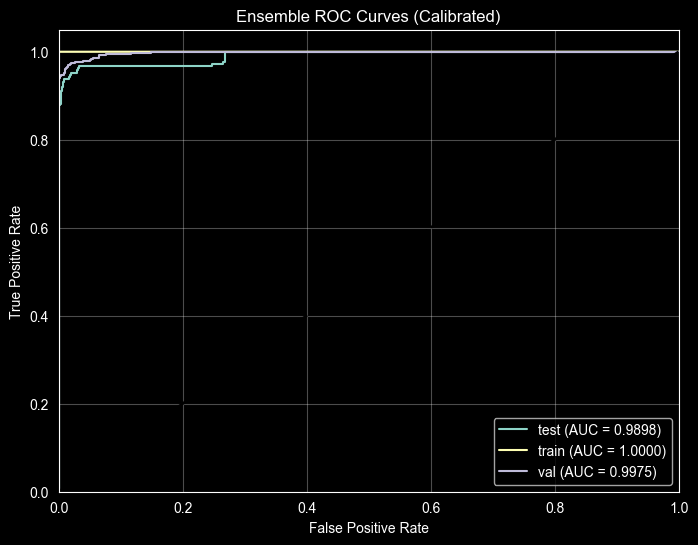

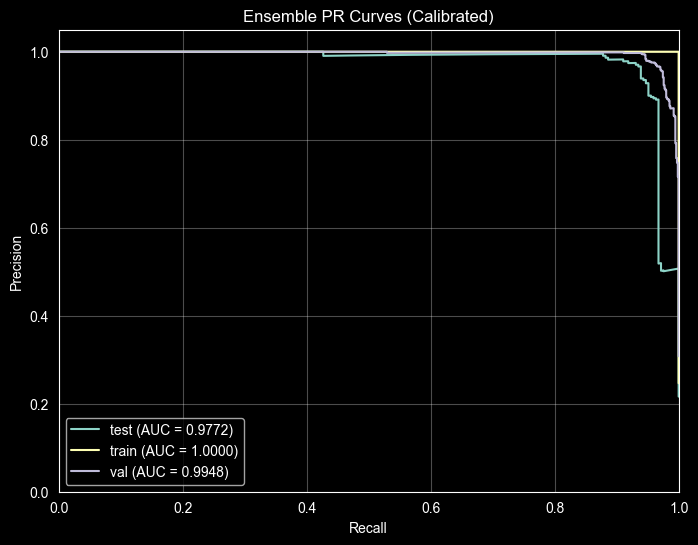

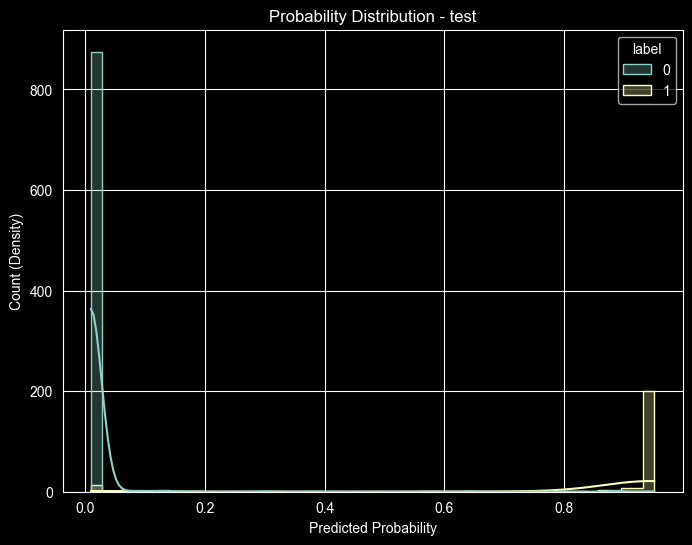

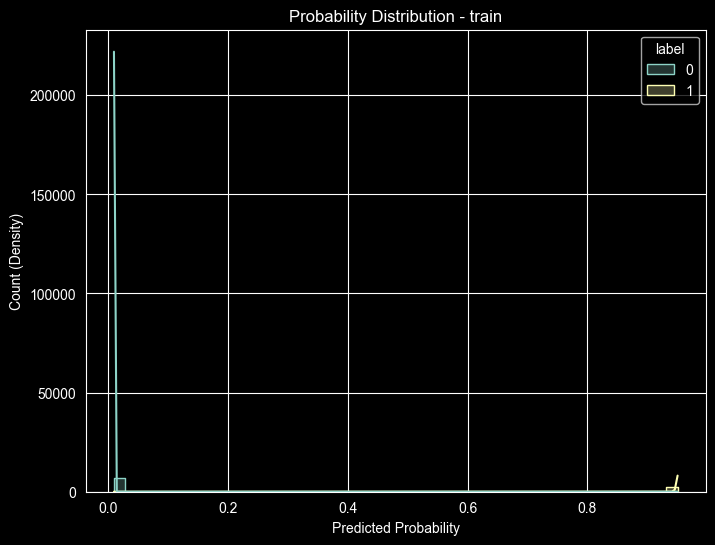

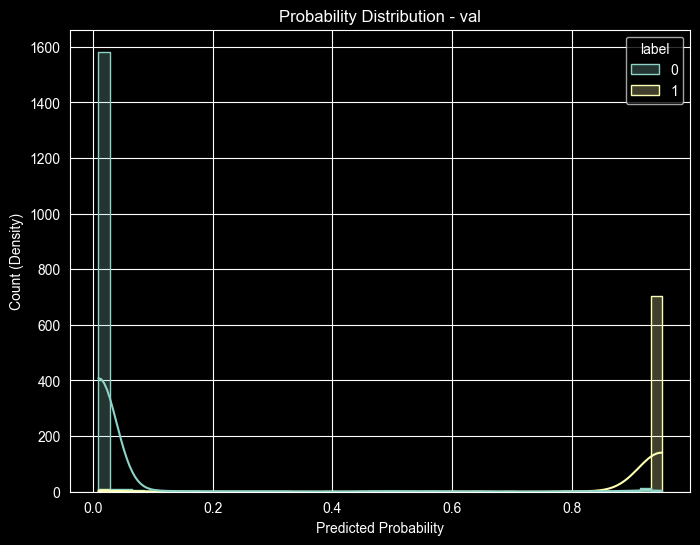

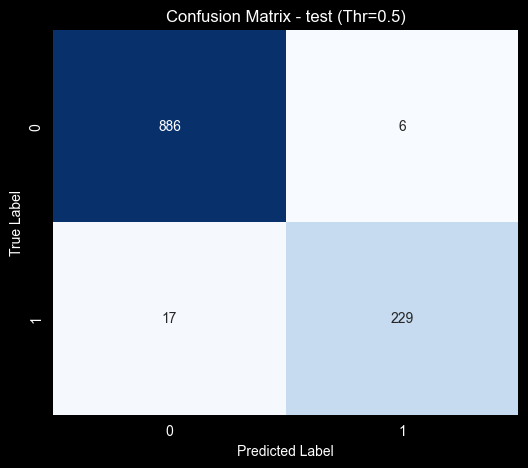

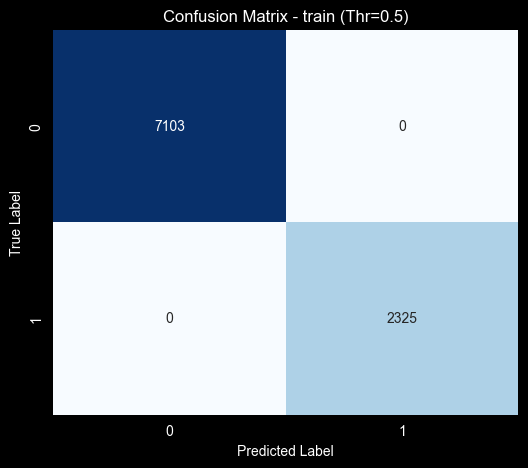

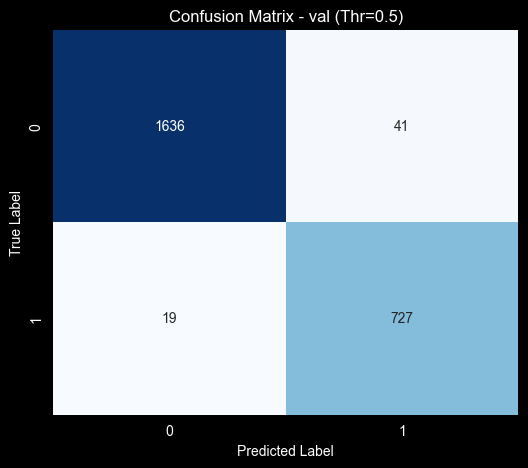

In [6]:
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

In [7]:
# 6. Dataset Distribution Check
print("\n--- Dataset Distribution Across Splits ---")
dist_table = df_all.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(dist_table)
pct_table = dist_table.div(dist_table.sum(axis=1), axis=0) * 100
print("\n--- Percentage Distribution ---")
print(pct_table.round(2))
if (dist_table == 0).any().any(): print("\nWARNING: Some splits are empty for a dataset!")
else: print("\nCONFIRMED: Both datasets are present in all splits")



--- Dataset Distribution Across Splits ---
split    test  train   val
dataset                   
iscx      337   3614   931
vnat      801   5814  1492

--- Percentage Distribution ---
split    test  train    val
dataset                    
iscx     6.90  74.03  19.07
vnat     9.88  71.72  18.40

CONFIRMED: Both datasets are present in all splits
